# 留存分析

**口径声明**：
- 队列（cohort）= 首日活跃日期相同的用户（如 11-25 首次活跃的 663 人）
- 第 N 天留存率 = 该队列中，首日后第 N 天仍活跃的人数 ÷ 队列总人数
- **右截断**：数据到 12-03 结束，晚队列（11-27 之后）算不出完整 day7，只展示可观测天数

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

url = URL.create(
    "mysql+pymysql",
    username="root",
    password=os.environ["MYSQL_PASSWORD"],
    host="localhost",
    port=3306,
    database="taobao_analysis",
    query={"charset": "utf8mb4"},
)
engine = create_engine(url)
print("连接成功")

连接成功


## 第 1 步：11-25 队列的 day0~day7 留存曲线

实现方式：队列取首日用户 → JOIN 每日活跃表 → `DATEDIFF` 算偏移天数 → `COUNT(DISTINCT CASE WHEN 偏移=N ...)` 逐天计数

> 注意：pandas 会把 SQL 里的 `%` 当格式化符处理，所以日期格式写 `%%Y-%%m-%%d`（发送到 MySQL 后自动还原为 `%Y-%m-%d`）。

In [2]:
curve = pd.read_sql(
    """
    WITH first_visit AS (
        SELECT user_id, MIN(FROM_UNIXTIME(ts,'%%Y-%%m-%%d')) AS first_dt
        FROM user_behavior GROUP BY user_id
    ),
    cohort AS (
        SELECT user_id FROM first_visit WHERE first_dt = '2017-11-25'
    ),
    active AS (
        SELECT DISTINCT user_id, FROM_UNIXTIME(ts,'%%Y-%%m-%%d') AS dt
        FROM user_behavior
    ),
    joined AS (
        SELECT c.user_id, DATEDIFF(a.dt, '2017-11-25') AS offset_day
        FROM cohort c
        LEFT JOIN active a ON a.user_id = c.user_id AND a.dt >= '2017-11-25'
    )
    SELECT
      COUNT(DISTINCT user_id) AS cohort_size,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=0 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day0,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=1 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day1,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=2 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day2,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=3 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day3,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=4 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day4,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=5 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day5,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=6 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day6,
      ROUND(COUNT(DISTINCT CASE WHEN offset_day=7 THEN user_id END)/COUNT(DISTINCT user_id),3) AS day7
    FROM joined
    """,
    con=engine,
)
curve

,cohort_size,day0,day1,day2,day3,day4,day5,day6,day7
0,663,1.0,0.792,0.783,0.778,0.781,0.757,0.753,0.98


## 第 2 步：画留存曲线（注意 day7 的异常突起）

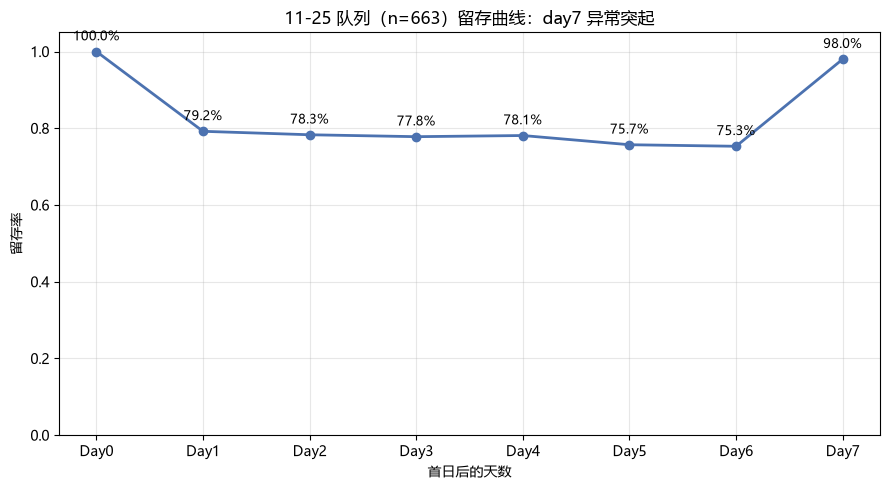

In [3]:
days = list(range(8))
rates = [curve[f"day{i}"].iloc[0] for i in days]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(days, rates, marker="o", linewidth=2, color="#4C72B0")
ax.set_xticks(days)
ax.set_xticklabels([f"Day{i}" for i in days])
ax.set_ylim(0, 1.05)
ax.set_ylabel("留存率")
ax.set_xlabel("首日后的天数")
ax.set_title("11-25 队列（n=663）留存曲线：day7 异常突起")
ax.grid(alpha=0.3)
for x, y in zip(days, rates):
    ax.annotate(f"{y:.1%}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(r"C:\Users\wukeyu31434\data-analyst-projects\taobao-user-behavior-analysis\reports\retention_curve.png", dpi=150)
plt.show()

## 第 3 步：多队列对比（11-24 / 11-25 / 11-26）

In [4]:
cohorts = pd.read_sql(
    """
    SELECT f.first_dt,
           COUNT(DISTINCT f.user_id) AS n,
           ROUND(COUNT(DISTINCT CASE WHEN DATEDIFF(d.dt,f.first_dt)=1 THEN d.user_id END)/COUNT(DISTINCT f.user_id),3) AS day1,
           ROUND(COUNT(DISTINCT CASE WHEN DATEDIFF(d.dt,f.first_dt)=3 THEN d.user_id END)/COUNT(DISTINCT f.user_id),3) AS day3,
           ROUND(COUNT(DISTINCT CASE WHEN DATEDIFF(d.dt,f.first_dt)=7 THEN d.user_id END)/COUNT(DISTINCT f.user_id),3) AS day7
    FROM (SELECT user_id, MIN(FROM_UNIXTIME(ts,'%%Y-%%m-%%d')) AS first_dt
          FROM user_behavior GROUP BY user_id) f
    LEFT JOIN (SELECT DISTINCT user_id, FROM_UNIXTIME(ts,'%%Y-%%m-%%d') AS dt
               FROM user_behavior) d
      ON f.user_id = d.user_id AND d.dt >= f.first_dt
    WHERE f.first_dt IN ('2017-11-24','2017-11-25','2017-11-26')
    GROUP BY f.first_dt
    ORDER BY f.first_dt
    """,
    con=engine,
)
cohorts

,first_dt,n,day1,day3,day7
0,2017-11-24,34,0.735,0.706,0.824
1,2017-11-25,663,0.792,0.778,0.980
2,2017-11-26,164,0.616,0.604,0.976


## 第 4 步：验证"活动日"假设

day7（12-02）留存突起是否因平台活动日所致？对比每天各行为类型的记录量，若 12-02/12-03 全行为类型同步上涨，则假设成立。

In [5]:
daily_pivot = pd.read_sql(
    """
    SELECT FROM_UNIXTIME(ts,'%%Y-%%m-%%d') AS dt,
           SUM(CASE WHEN behavior_type='pv'   THEN 1 ELSE 0 END) AS pv,
           SUM(CASE WHEN behavior_type='cart' THEN 1 ELSE 0 END) AS cart,
           SUM(CASE WHEN behavior_type='buy'  THEN 1 ELSE 0 END) AS buy
    FROM user_behavior
    WHERE ts >= UNIX_TIMESTAMP('2017-11-25')
    GROUP BY dt
    ORDER BY dt
    """,
    con=engine,
)
daily_pivot

,dt,pv,cart,buy
0,2017-11-25,9106.0,533.0,179.0
1,2017-11-26,9350.0,536.0,215.0
2,2017-11-27,8782.0,527.0,250.0
3,2017-11-28,9385.0,572.0,221.0
4,2017-11-29,9477.0,579.0,221.0
5,2017-11-30,9225.0,539.0,259.0
6,2017-12-01,10290.0,643.0,214.0
7,2017-12-02,12273.0,796.0,270.0
8,2017-12-03,11777.0,721.0,272.0


In [6]:
# 把 12-02/12-03 和之前均值对比
early = daily_pivot[daily_pivot['dt'] < '2017-12-02']
late = daily_pivot[daily_pivot['dt'] >= '2017-12-02']
compare = pd.DataFrame({
    '平常日均值(11-25~12-01)': early[['pv','cart','buy']].mean().round(0),
    '12-02': late[late['dt']=='2017-12-02'][['pv','cart','buy']].iloc[0],
    '12-03': late[late['dt']=='2017-12-03'][['pv','cart','buy']].iloc[0],
})
compare

,平常日均值(11-25~12-01),12-02,12-03
pv,9374.0,12273.0,11777.0
cart,561.0,796.0,721.0
buy,223.0,270.0,272.0


## 报告

完整业务解读（曲线形状、运营日历效应、队列差异检验）见 `reports/retention_insights.md`。